---

# ASSIGNMENT 4: WORKING WITH `.shirt()` AND `.diff()`

---

In [5]:
import numpy as np
import pandas as pd

In [6]:
transactions = pd.read_parquet('../Data/transactions.parquet')
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


<br><br>

---


## Solution No.1 - Working with `.assign()` Method

In [7]:
df = transactions.query("date.dt.year in [2014, 2015] and store_nbr == 47")

df = df.assign(month = df.date.dt.month,
         year = df.date.dt.year)

df = df.pivot_table(index='month', columns='year', values='transactions', aggfunc='sum')

df

year,2014,2015
month,,
1,114190,118445
2,107175,108186
3,121771,119883
4,122976,118449
5,126298,120810
6,118398,110814
7,118522,116234
8,121949,119307
9,115552,112975


<Axes: xlabel='month'>

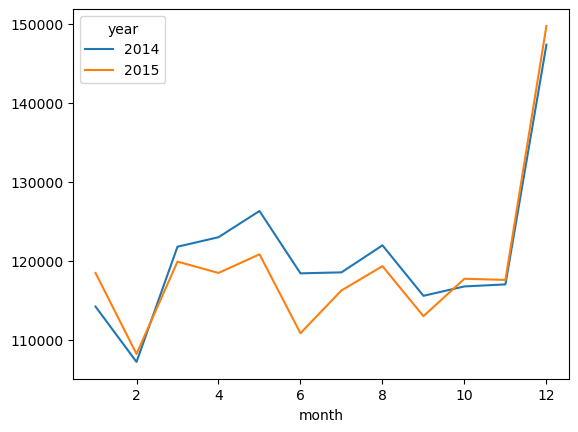

In [8]:
df.plot()

<br><br>

---


## Solution No.2 - Working with `.groupby()` Method

In [12]:
df2 = transactions.query('date.dt.year in [2014, 2015] and store_nbr == 47')

df2 = df2.groupby([df2.date.dt.year, df2.date.dt.month])[['transactions']].sum()
df2

transactions
date date              
2014 1           114190
     2           107175
     3           121771
     4           122976
     5           126298
     6           118398
     7           118522
     8           121949
     9           115552
     10          116741
     11          116996
     12          147371
2015 1           118445
     2           108186
     3           119883
     4           118449
     5           120810
     6           110814
     7           116234
     8           119307
     9           112975
     10          117712
     11          117564
     12          149747

In [13]:
df2['year_prior'] = df2.transactions.shift(12)
df2

transactions  year_prior
date date                          
2014 1           114190         NaN
     2           107175         NaN
     3           121771         NaN
     4           122976         NaN
     5           126298         NaN
     6           118398         NaN
     7           118522         NaN
     8           121949         NaN
     9           115552         NaN
     10          116741         NaN
     11          116996         NaN
     12          147371         NaN
2015 1           118445    114190.0
     2           108186    107175.0
     3           119883    121771.0
     4           118449    122976.0
     5           120810    126298.0
     6           110814    118398.0
     7           116234    118522.0
     8           119307    121949.0
     9           112975    115552.0
     10          117712    116741.0
     11          117564    116996.0
     12          149747    147371.0

In [16]:
df2.index

MultiIndex([(2014,  1),
            (2014,  2),
            (2014,  3),
            (2014,  4),
            (2014,  5),
            (2014,  6),
            (2014,  7),
            (2014,  8),
            (2014,  9),
            (2014, 10),
            (2014, 11),
            (2014, 12),
            (2015,  1),
            (2015,  2),
            (2015,  3),
            (2015,  4),
            (2015,  5),
            (2015,  6),
            (2015,  7),
            (2015,  8),
            (2015,  9),
            (2015, 10),
            (2015, 11),
            (2015, 12)],
           names=['date', 'date'])

In [19]:
df2 = df2.loc[(2015)]
df2

,transactions,year_prior
date,,
1,118445,114190.0
2,108186,107175.0
3,119883,121771.0
4,118449,122976.0
5,120810,126298.0
6,110814,118398.0
7,116234,118522.0
8,119307,121949.0
9,112975,115552.0


<Axes: xlabel='date'>

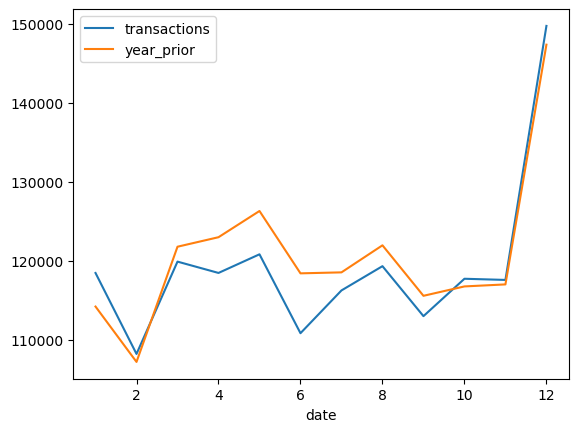

In [20]:
df2.plot()